# SIB Cathode Property Prediction — XGBoost Baseline

**Project**: Predict Sodium-Ion Battery (Prussian Blue Analog) cathode performance from composition + synthesis + protocol conditions.
**Dataset**: 50-row dummy dataset (14 chemistry families) — `sib_cathode_dummy_dataset.csv`
**Model**: XGBoost multi-target regression as production baseline.

---

## Task Overview

Given a candidate PBA composition (e.g., `Na1.9Fe0.75Mn0.25[Fe(CN)6]`) and testing protocol, predict five performance targets:

| Target | Meaning | Business use |
|---|---|---|
| `specific_capacity_mAhg` | Reversible charge per gram | **Primary target** — energy density |
| `capacity_retention_pct` | % after 100 cycles | Cycle life proxy |
| `avg_voltage_V` | Weighted avg discharge V | Energy = Q × V |
| `ICE_pct` | First-cycle Coulombic efficiency | Manufacturing quality |
| `rate_cap_1C_5C_pct` | Fast-discharge capability | Application fit (EV vs stationary) |

Primary target for this baseline: **`specific_capacity_mAhg`**. Other targets trained as separate models (multi-task with independent XGBoost regressors).

## Small-Dataset Challenge

n=50 is **tiny** for ML. Standard practice:
- Composition-grouped splits (prevent leakage: same composition at multiple C-rates cannot split across train/test)
- Cross-validation over point estimates (small holdout misleading)
- Emphasis on interpretability + physics sanity over squeeze-the-last-1% MAPE
- Baseline sets floor for later PIML / physics-informed feature comparison

## Notebook Structure

1. Setup + Configuration
2. Data Loading + Schema Validation
3. Exploratory Data Analysis
4. Data Preparation (categorical encoding, missing handling, composition-grouped split)
5. Baseline Model (default XGBoost, single target)
6. Hyperparameter Tuning
7. Final Model Training
8. Evaluation
9. Multi-target extension (all 5 targets)
10. Interpretability (feature importance + SHAP)
11. Error Analysis by Chemistry Family
12. Model Persistence + Prediction Function
13. Production Readiness Checklist

**Author**: Hussnain Tariq
**Model version**: sib-xgb-v1-baseline

---
## 1. Setup

### 1.1 Imports

In [3]:
import os
import json
import warnings
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, GroupKFold, cross_val_score,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_percentage_error, mean_absolute_error,
    root_mean_squared_error, r2_score,
)
from sklearn.inspection import permutation_importance
import xgboost as xgb

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

import joblib

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print(f'numpy   : {np.__version__}')
print(f'pandas  : {pd.__version__}')
print(f'xgboost : {xgb.__version__}')
print(f'shap    : {shap.__version__ if HAS_SHAP else "not installed"}')

numpy   : 2.4.6
pandas  : 3.0.5
xgboost : 3.2.0
shap    : 0.51.0


### 1.2 Configuration

In [4]:
@dataclass
class Config:
    # Paths
    data_path: str = 'sib_cathode_dummy_dataset.csv'
    output_dir: str = 'artifacts/'
    model_name: str = 'sib_xgb_baseline_v1'

    # Reproducibility
    random_seed: int = 42

    # Targets — primary is specific_capacity_mAhg; others trained as separate models
    primary_target: str = 'specific_capacity_mAhg'
    all_targets: tuple = (
        'specific_capacity_mAhg',
        'capacity_retention_pct',
        'avg_voltage_V',
        'ICE_pct',
        'rate_cap_1C_5C_pct',
    )

    # Split strategy — composition-grouped to prevent leakage
    test_size: float = 0.20
    cv_folds: int = 5

    # XGBoost search space (small for small dataset)
    xgb_search_space: dict = field(default_factory=lambda: {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.03, 0.05, 0.1],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.7, 0.85, 1.0],
        'colsample_bytree': [0.7, 0.85, 1.0],
        'reg_alpha': [0, 0.01, 0.1],
        'reg_lambda': [1, 3, 10],
    })

    xgb_fixed_params: dict = field(default_factory=lambda: {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1,
    })


CFG = Config()
Path(CFG.output_dir).mkdir(exist_ok=True, parents=True)
np.random.seed(CFG.random_seed)

print('Configuration:')
for k, v in asdict(CFG).items():
    if isinstance(v, (list, tuple)) and len(v) > 5:
        print(f'  {k}: [{len(v)} items]')
    elif isinstance(v, dict):
        print(f'  {k}:')
        for kk, vv in v.items():
            print(f'    {kk}: {vv}')
    else:
        print(f'  {k}: {v}')

Configuration:
  data_path: sib_cathode_dummy_dataset.csv
  output_dir: artifacts/
  model_name: sib_xgb_baseline_v1
  random_seed: 42
  primary_target: specific_capacity_mAhg
  all_targets: ('specific_capacity_mAhg', 'capacity_retention_pct', 'avg_voltage_V', 'ICE_pct', 'rate_cap_1C_5C_pct')
  test_size: 0.2
  cv_folds: 5
  xgb_search_space:
    n_estimators: [100, 200, 300]
    max_depth: [3, 4, 5]
    learning_rate: [0.03, 0.05, 0.1]
    min_child_weight: [1, 3, 5]
    subsample: [0.7, 0.85, 1.0]
    colsample_bytree: [0.7, 0.85, 1.0]
    reg_alpha: [0, 0.01, 0.1]
    reg_lambda: [1, 3, 10]
  xgb_fixed_params:
    objective: reg:squarederror
    tree_method: hist
    random_state: 42
    verbosity: 0
    n_jobs: -1


---
## 2. Data Loading + Schema Validation

In [5]:
def load_and_validate(path, cfg):
    if not Path(path).exists():
        raise FileNotFoundError(f'Dataset not found: {path}')

    df = pd.read_csv(path)

    # Schema checks
    assert 'formula' in df.columns, 'formula column missing'
    assert df['formula'].notna().all(), 'Some rows missing formula'
    assert cfg.primary_target in df.columns, f'{cfg.primary_target} missing'
    assert df[cfg.primary_target].notna().all(), f'{cfg.primary_target} has NaN (should be complete)'
    assert (df[cfg.primary_target] > 0).all(), 'Non-positive capacity values'

    print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
    return df


df = load_and_validate(CFG.data_path, CFG)
df.head(3)

Loaded: 50 rows × 82 columns


,formula,na_stoichiometry,fe_fraction,mn_fraction,co_fraction,ni_fraction,cu_fraction,zn_fraction,vacancy_fraction,water_content,c_rate,voltage_min_V,voltage_max_V,test_temp_C,electrolyte,specific_capacity_mAhg,avg_voltage_V,capacity_retention_pct,ICE_pct,rate_cap_1C_5C_pct,synth_temp_C,synth_pH,precursor_conc_M,aging_time_h,paper_doi,paper_year,lab_group,notes,mp_material_id,mp_formula_matched,mp_formation_energy_per_atom,mp_energy_above_hull,mp_band_gap,mp_volume,mp_density,mp_nsites,mp_volume_per_atom,mm_mean_atomic_weight,mm_mean_mendeleev_num,mm_mean_atomic_radius,mm_mean_electronegativity,mm_mean_s_valence,mm_mean_d_valence,mm_mean_f_valence,mm_mean_total_valence,mm_mean_s_unfilled,mm_mean_d_unfilled,mm_mean_total_unfilled,mm_mean_gs_volume_pa,mm_mean_gs_bandgap,mm_mean_gs_magmom,mm_mean_spacegroup,mm_mean_covalent_radius,mm_range_atomic_radius,mm_range_electronegativity,mm_range_d_valence,mm_avgdev_electronegativity,mm_avgdev_atomic_radius,mm_max_electronegativity,mm_min_electronegativity,mm_mean_ionization_energy,mm_mean_electron_affinity,mm_mean_row,mm_mean_column,mm_std_atomic_radius,mm_std_electronegativity,mm_n_elements,mm_stoichiometry_entropy,pba_weighted_ionic_radius,pba_ionic_radius_mismatch,pba_weighted_d_electrons,pba_jt_active_fraction,pba_n_redox_active_metals,pba_theoretical_capacity,pba_charge_balance,pba_substitution_entropy,pba_jt_active_bool,pba_redox_potential_estimate,pba_framework_rigidity,pba_na_vacancy_fraction,pba_na_vacancy_ordered,pba_water_content_normalized
0,Na2Fe[Fe(CN)6],2.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,C/10,2.0,4.0,25.0,1M NaClO4 PC,161.5,3.10,86.1,92.9,74.1,80.0,5.0,0.1,24.0,10.9999/dummy.001,2022,Altris AB,Pure PW baseline: Fully sodiated pure PW — ref...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.612500,80.000000,0.952500,2.441250,1.875000,0.750000,0.0,4.500000,0.125000,0.500000,0.625000,13.375000,2.062500,0.937500,202.750000,0.923750,1.05,2.11,6,0.530625,0.288750,3.04,0.93,11.301250,0.560000,2.375000,12.000000,0.359818,0.686339,2,1.255482,0.78,0.0,6.0,0.0,1,170.00,1.000,0.0,0,3.15,1.0,0.000,1.0,0.0
1,Na1.95Fe[Fe(CN)6],1.95,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,C/10,2.0,4.0,25.0,1M NaClO4 PC,156.6,3.13,85.0,91.1,79.8,80.0,5.0,0.1,24.0,10.9999/dummy.002,2023,Altris AB,Pure PW baseline: Slightly Na-deficient (as-ma...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.601912,80.216301,0.949843,2.445987,1.877743,0.752351,0.0,4.510972,0.122257,0.501567,0.623824,13.293103,2.068966,0.938871,202.667712,0.921442,1.05,2.11,6,0.525160,0.285658,3.04,0.93,11.320564,0.560031,2.373041,12.034483,0.357234,0.682170,2,1.252865,0.78,0.0,6.0,0.0,1,165.75,0.975,0.0,0,3.15,1.0,0.025,1.0,0.0
2,Na1.9Fe[Fe(CN)6],1.90,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,C/10,2.0,4.0,25.0,1M NaClO4 PC,152.3,3.21,85.7,91.1,78.7,80.0,5.0,0.1,24.0,10.9999/dummy.003,2023,Altris AB,Pure PW baseline: Common as-synthesised PW com...,mp-843316,Na1.9Fe[Fe(CN)6],-1.421,0.1137,1.209,545.6,2.336,28.0,20.227,19.591258,80.433962,0.947170,2.450755,1.880503,0.754717,0.0,4.522013,0.119497,0.503145,0.622642,13.210692,2.075472,0.940252,202.584906,0.919119,1.05,2.11,6,0.519616,0.282520,3.04,0.93,11.340000,0.560063,2.371069,12.069182,0.354595,0.677915,2,1.250160,0.78,0.0,6.0,0.0,1,161.50,0.950,0.0,0,3.15,1.0,0.050,1.0,0.0


### 2.1 Column groups

82 columns organized into logical groups.

In [6]:
COL_GROUPS = {
    'composition_raw': [
        'formula', 'na_stoichiometry', 'fe_fraction', 'mn_fraction',
        'co_fraction', 'ni_fraction', 'cu_fraction', 'zn_fraction',
        'vacancy_fraction', 'water_content',
    ],
    'protocol': [
        'c_rate', 'voltage_min_V', 'voltage_max_V', 'test_temp_C', 'electrolyte',
    ],
    'synthesis': [
        'synth_temp_C', 'synth_pH', 'precursor_conc_M', 'aging_time_h',
    ],
    'targets': list(CFG.all_targets),
    'provenance': ['paper_doi', 'paper_year', 'lab_group', 'notes'],
    'mp_features': [c for c in df.columns if c.startswith('mp_')],
    'mm_features': [c for c in df.columns if c.startswith('mm_')],
    'pba_features': [c for c in df.columns if c.startswith('pba_')],
}

for group, cols in COL_GROUPS.items():
    print(f'{group:20s}: {len(cols):3d} columns')

# Sanity
all_grouped = sum([c for c in COL_GROUPS.values()], [])
uncovered = [c for c in df.columns if c not in all_grouped]
print(f'\nUncovered columns: {uncovered}')

composition_raw     :  10 columns
protocol            :   5 columns
synthesis           :   4 columns
targets             :   5 columns
provenance          :   4 columns
mp_features         :   9 columns
mm_features         :  31 columns
pba_features        :  14 columns

Uncovered columns: []


### 2.2 Missing value audit

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
missing_df = missing_df[missing_df['n_missing'] > 0].sort_values('n_missing', ascending=False)
print(f'Columns with missing values ({len(missing_df)}):')
print(missing_df.to_string())

Columns with missing values (16):
                              n_missing  pct_missing
mp_material_id                       19         38.0
mp_nsites                            19         38.0
mp_density                           19         38.0
mp_volume                            19         38.0
mp_band_gap                          19         38.0
mp_energy_above_hull                 19         38.0
mp_formation_energy_per_atom         19         38.0
mp_formula_matched                   19         38.0
mp_volume_per_atom                   19         38.0
aging_time_h                          1          2.0
synth_pH                              1          2.0
precursor_conc_M                      1          2.0
ICE_pct                               1          2.0
rate_cap_1C_5C_pct                    1          2.0
capacity_retention_pct                1          2.0
synth_temp_C                          1          2.0


---
## 3. Exploratory Data Analysis

### 3.1 Target distributions

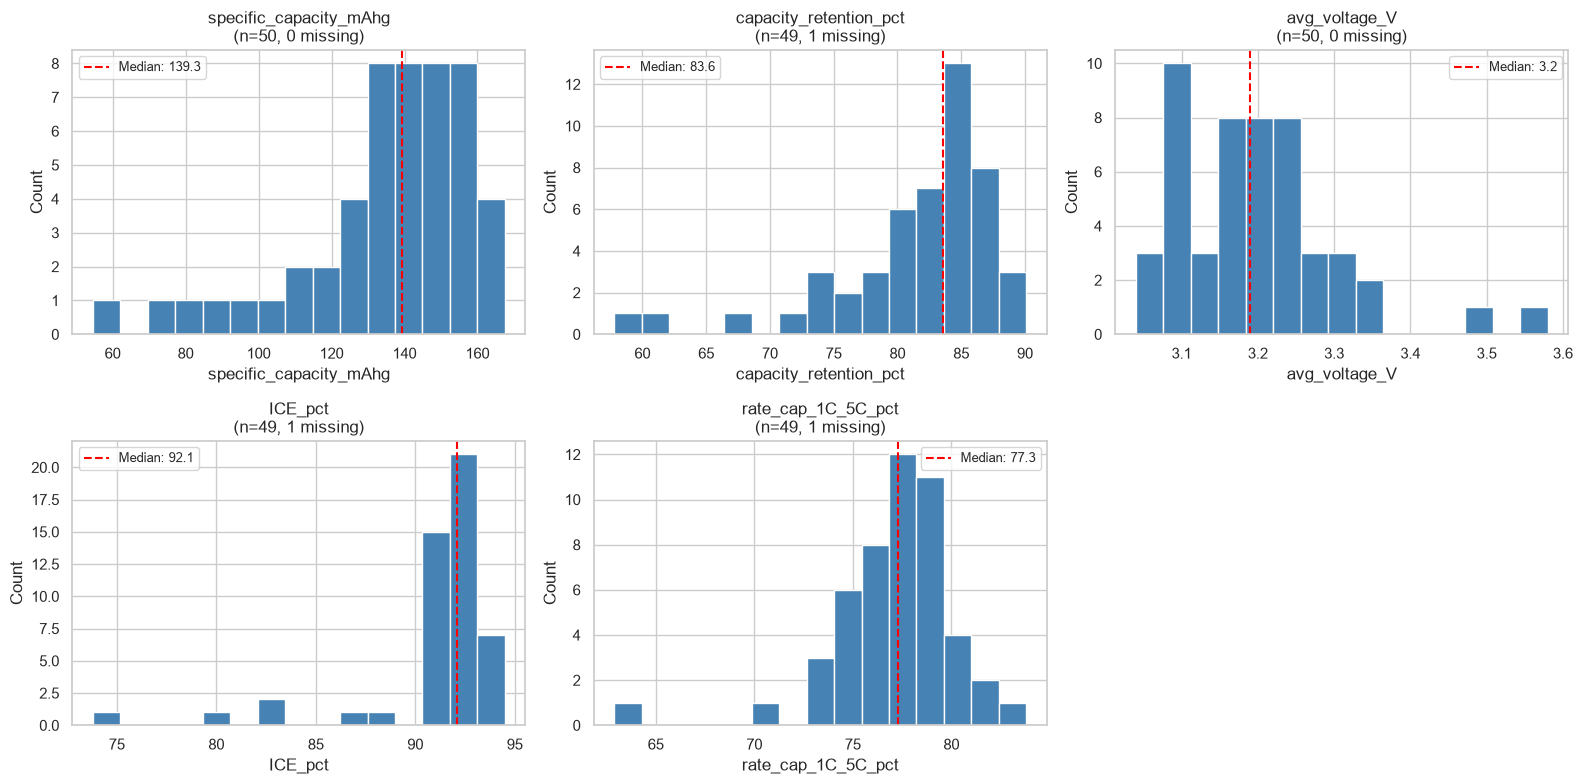

Target statistics:


,mean,std,min,50%,max
specific_capacity_mAhg,134.82,24.18,54.60,139.35,167.50
capacity_retention_pct,81.52,6.60,57.80,83.60,90.10
avg_voltage_V,3.20,0.10,3.04,3.19,3.58
ICE_pct,91.08,3.75,73.80,92.10,94.50
rate_cap_1C_5C_pct,77.13,3.14,62.90,77.30,83.80


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, target in zip(axes, CFG.all_targets):
    vals = df[target].dropna()
    ax.hist(vals, bins=15, edgecolor='white', color='steelblue')
    ax.axvline(vals.median(), color='red', linestyle='--',
               label=f'Median: {vals.median():.1f}')
    ax.set_xlabel(target)
    ax.set_ylabel('Count')
    ax.set_title(f'{target}\n(n={len(vals)}, {df[target].isna().sum()} missing)')
    ax.legend(fontsize=9)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

print('Target statistics:')
df[list(CFG.all_targets)].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2)

### 3.2 Chemistry family visualization

Different families should show distinct patterns.

In [9]:
# Categorize each row into a family based on composition
def classify_family(row):
    if row['vacancy_fraction'] > 0.01:
        return 'Vacancy variants'
    if row['water_content'] > 0.01:
        return 'Hydrated'
    if row['test_temp_C'] > 30:
        return 'Elevated-T'
    if row['electrolyte'] not in ('1M NaClO4 PC',):
        return 'Alt electrolyte'
    if (row['voltage_min_V'], row['voltage_max_V']) != (2.0, 4.0):
        return 'V-window variation'
    non_fe = row['mn_fraction'] + row['co_fraction'] + row['ni_fraction'] + row['cu_fraction'] + row['zn_fraction']
    if non_fe < 0.01:
        return 'Pure PW'
    # Substitution family
    subs = {
        'Mn-sub': row['mn_fraction'],
        'Co-sub': row['co_fraction'],
        'Ni-sub': row['ni_fraction'],
        'Cu-sub': row['cu_fraction'],
        'Zn-sub': row['zn_fraction'],
    }
    active = {k: v for k, v in subs.items() if v > 0.01}
    if len(active) == 1:
        return list(active.keys())[0]
    elif len(active) >= 2:
        return 'Multi-metal'
    return 'Other'


df['family'] = df.apply(classify_family, axis=1)
print('Family distribution:')
print(df['family'].value_counts())

Family distribution:
family
Mn-sub                12
Pure PW                8
V-window variation     7
Alt electrolyte        6
Cu-sub                 3
Zn-sub                 3
Multi-metal            3
Vacancy variants       3
Hydrated               3
Co-sub                 1
Elevated-T             1
Name: count, dtype: int64


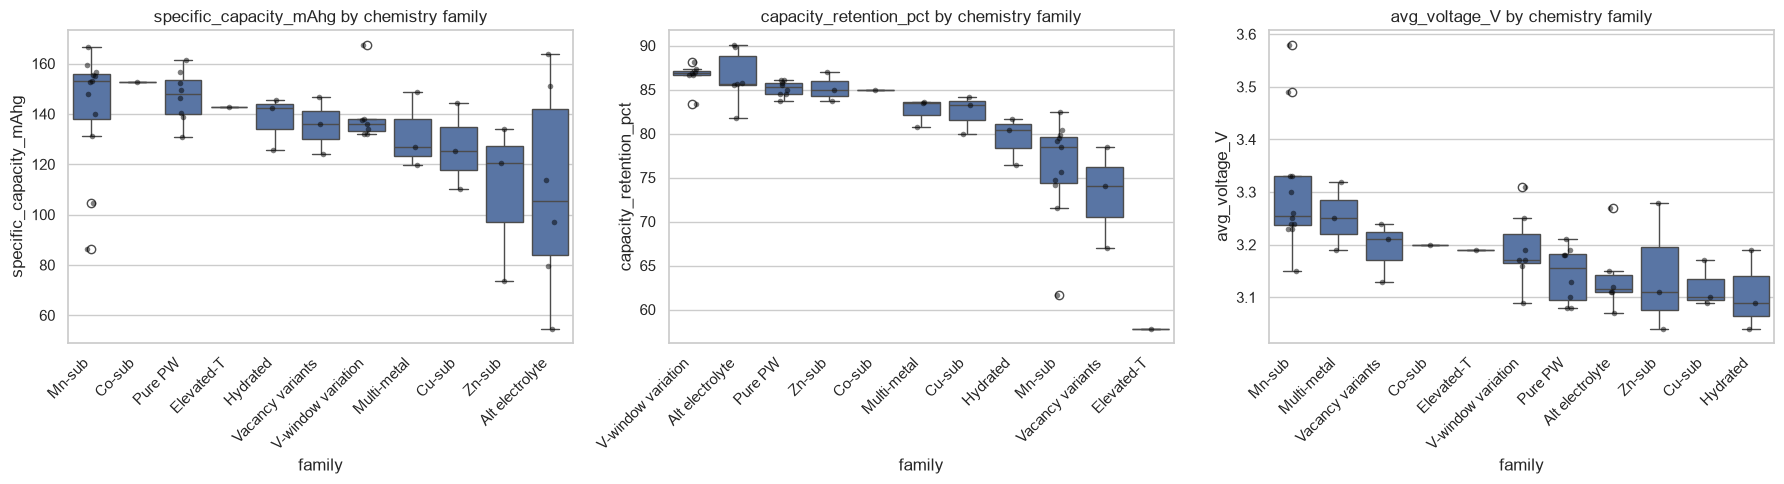

In [10]:
# Visualize targets by family
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, ['specific_capacity_mAhg', 'capacity_retention_pct', 'avg_voltage_V']):
    order = df.groupby('family')[target].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='family', y=target, order=order, ax=ax)
    sns.stripplot(data=df, x='family', y=target, order=order, ax=ax,
                  size=4, color='black', alpha=0.5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(f'{target} by chemistry family')

plt.tight_layout()
plt.show()

### 3.3 Feature correlations with primary target

e:\AI Engineer Material\AI Engineer\Cathode Screening\SIB_Cathode\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
e:\AI Engineer Material\AI Engineer\Cathode Screening\SIB_Cathode\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


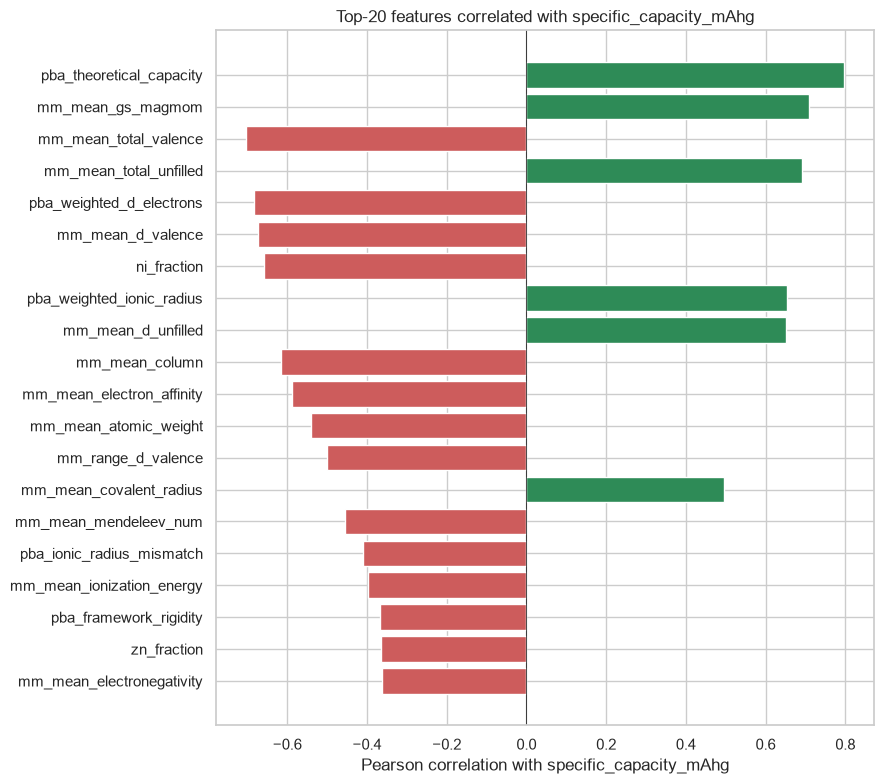


Top-5 predictive features:
pba_theoretical_capacity    0.796910
mm_mean_gs_magmom           0.707881
mm_mean_total_valence      -0.703446
mm_mean_total_unfilled      0.691662
pba_weighted_d_electrons   -0.684227


In [11]:
# Numeric features only (exclude targets and provenance)
feature_cols_all = [c for c in df.columns
                    if c not in COL_GROUPS['targets']
                    and c not in COL_GROUPS['provenance']
                    and c not in ('formula', 'family')
                    and df[c].dtype in (np.float64, np.int64)]

target = df[CFG.primary_target]
corrs = df[feature_cols_all].apply(lambda col: col.corr(target))
corrs = corrs.dropna().sort_values(key=abs, ascending=False)

# Show top 20
top20 = corrs.head(20)
fig, ax = plt.subplots(figsize=(9, 8))
colors = ['seagreen' if v > 0 else 'indianred' for v in top20.values]
ax.barh(range(len(top20)), top20.values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index)
ax.set_xlabel(f'Pearson correlation with {CFG.primary_target}')
ax.set_title(f'Top-20 features correlated with {CFG.primary_target}')
ax.axvline(0, color='black', lw=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'\nTop-5 predictive features:')
print(top20.head().to_string())

---
## 4. Data Preparation

### 4.1 Feature selection

Drop columns that would leak (other targets, provenance, chemistry family) or are constant.

In [12]:
# Feature columns: everything except targets, provenance, formula string, family label, MP IDs
DROP_COLS = (list(CFG.all_targets) + COL_GROUPS['provenance']
             + ['formula', 'family', 'mp_material_id', 'mp_formula_matched'])
feature_cols = [c for c in df.columns if c not in DROP_COLS]

# Split by type
categorical_cols = ['c_rate', 'electrolyte']
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print(f'Feature columns: {len(feature_cols)} total')
print(f'  Numeric:     {len(numeric_cols)}')
print(f'  Categorical: {len(categorical_cols)} → {categorical_cols}')

Feature columns: 70 total
  Numeric:     68
  Categorical: 2 → ['c_rate', 'electrolyte']


### 4.2 Preprocessing pipeline

- Numeric: median imputation (safe default; XGBoost handles NaN natively but we impute for reproducibility)
- Categorical: one-hot encoding

In [13]:
def build_preprocessor(numeric_cols, categorical_cols):
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols),
    ], remainder='drop')


preprocessor = build_preprocessor(numeric_cols, categorical_cols)
print('Preprocessing pipeline built.')

Preprocessing pipeline built.


### 4.3 Composition-grouped train/test split

**Critical for this dataset**: same composition (e.g., `Na1.9Fe0.75Mn0.25`) appears 8+ times with different C-rates.

If we do random split, model 'sees' composition A at C/10 in train and composition A at 5C in test — that's not extrapolation to new materials, that's protocol interpolation on known material.

**Composition-grouped split** ensures each unique composition ends up entirely in train OR entirely in test — measures true generalization to new materials.

In [14]:
# Build grouping key from composition (formula without water suffix)
df['composition_key'] = df['formula'].str.split('·').str[0]
n_unique_comp = df['composition_key'].nunique()
print(f'Unique compositions: {n_unique_comp} (out of {len(df)} rows)')
print(f'Compositions with multiple rows:')
multi = df.groupby('composition_key').size()
multi = multi[multi > 1].sort_values(ascending=False)
print(multi.to_string())

Unique compositions: 34 (out of 50 rows)
Compositions with multiple rows:
composition_key
Na1.9Fe0.75Mn0.25[Fe(CN)6]    9
Na1.9Fe[Fe(CN)6]              9


In [15]:
from sklearn.model_selection import GroupShuffleSplit

X_all = df[feature_cols]
y_all = df[CFG.primary_target]
groups = df['composition_key']

gss = GroupShuffleSplit(n_splits=1, test_size=CFG.test_size, random_state=CFG.random_seed)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print(f'Train: {len(X_train)} rows | {groups_train.nunique()} unique compositions')
print(f'Test:  {len(X_test)} rows | {groups.iloc[test_idx].nunique()} unique compositions')

# Verify no leakage
assert set(groups_train).isdisjoint(set(groups.iloc[test_idx])), 'COMPOSITION LEAKAGE!'
print('\n✓ No composition leakage across train/test')

Train: 43 rows | 27 unique compositions
Test:  7 rows | 7 unique compositions

✓ No composition leakage across train/test


---
## 5. Baseline Model — Default XGBoost

Sanity-check with default params. This is the reference number.

In [16]:
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        random_state=CFG.random_seed, verbosity=0, n_jobs=-1,
    )),
])

baseline_pipeline.fit(X_train, y_train)

pred_train = baseline_pipeline.predict(X_train)
pred_test = baseline_pipeline.predict(X_test)


def evaluate(y_true, y_pred, label):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label:15s}  MAPE: {mape:5.2f}%  |  MAE: {mae:5.2f}  |  '
          f'RMSE: {rmse:5.2f}  |  R²: {r2:+.3f}')
    return {'mape': mape, 'mae': mae, 'rmse': rmse, 'r2': r2}


print('=' * 70)
print('BASELINE (default hyperparameters)')
print('=' * 70)
baseline_train_metrics = evaluate(y_train, pred_train, 'Train')
baseline_test_metrics = evaluate(y_test, pred_test, 'Test')
print(f'\nTrain → Test MAPE gap: {baseline_test_metrics["mape"] - baseline_train_metrics["mape"]:+.2f}%')

BASELINE (default hyperparameters)
Train            MAPE:  0.55%  |  MAE:  0.70  |  RMSE:  0.90  |  R²: +0.999
Test             MAPE:  3.61%  |  MAE:  4.66  |  RMSE:  5.64  |  R²: +0.950

Train → Test MAPE gap: +3.05%


---
## 6. Hyperparameter Tuning

**Approach**: RandomizedSearch with GroupKFold CV on training set — respects composition groups.

In [19]:
base_xgb = xgb.XGBRegressor(**CFG.xgb_fixed_params)

# Wrap in pipeline for search
search_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(numeric_cols, categorical_cols)),
    ('model', base_xgb),
])

# Search space with 'model__' prefix (pipeline convention)
search_space = {f'model__{k}': v for k, v in CFG.xgb_search_space.items()}

# GroupKFold for composition-aware CV
group_kf = GroupKFold(n_splits=CFG.cv_folds)

random_search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=search_space,
    n_iter=40,
    scoring='neg_mean_absolute_percentage_error',
    cv=list(group_kf.split(X_train, y_train, groups_train)),
    random_state=CFG.random_seed,
    n_jobs=-1,
    verbose=0,
    refit=True,
)

print(f'Running randomized search (40 iterations × {CFG.cv_folds} folds = 200 fits)...')
random_search.fit(X_train, y_train)

print(f'\nBest CV MAPE: {-random_search.best_score_ * 100:.2f}%')
print(f'\nBest hyperparameters:')
for k, v in random_search.best_params_.items():
    print(f'  {k.replace("model__", "")}: {v}')

Running randomized search (40 iterations × 5 folds = 200 fits)...

Best CV MAPE: 11.69%

Best hyperparameters:
  subsample: 0.85
  reg_lambda: 3
  reg_alpha: 0.01
  n_estimators: 200
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 0.7


In [20]:
# Top-10 configurations
cv_results = pd.DataFrame(random_search.cv_results_)
top10 = cv_results.nsmallest(10, 'rank_test_score')[
    ['mean_test_score', 'std_test_score', 'params']
].reset_index(drop=True)
top10['cv_mape_pct'] = (-top10['mean_test_score'] * 100).round(2)
top10['std_pct'] = (top10['std_test_score'] * 100).round(2)
print('Top-10 hyperparameter configurations:')
top10[['cv_mape_pct', 'std_pct']]

Top-10 hyperparameter configurations:


,cv_mape_pct,std_pct
0,11.69,6.73
1,11.74,6.82
2,11.86,6.42
3,11.98,5.58
4,11.99,7.16
5,12.00,7.02
6,12.01,6.79
7,12.03,5.76
8,12.04,7.18
9,12.22,6.70


---
## 7. Final Model Training

Retrain with best hyperparameters + early stopping on internal validation split.

In [21]:
# Split train further for early-stopping validation (composition-grouped)
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=CFG.random_seed)
inner_train_idx, inner_val_idx = next(gss_inner.split(X_train, y_train, groups_train))

X_inner_train = X_train.iloc[inner_train_idx]
y_inner_train = y_train.iloc[inner_train_idx]
X_inner_val = X_train.iloc[inner_val_idx]
y_inner_val = y_train.iloc[inner_val_idx]

print(f'Inner train: {len(X_inner_train)} rows')
print(f'Inner val:   {len(X_inner_val)} rows')

# Preprocess separately (fit on inner train only)
prep_final = build_preprocessor(numeric_cols, categorical_cols)
X_inner_train_p = prep_final.fit_transform(X_inner_train)
X_inner_val_p = prep_final.transform(X_inner_val)
X_test_p = prep_final.transform(X_test)

# Final XGBoost with best params + early stopping
best_params = {**CFG.xgb_fixed_params,
               **{k.replace('model__', ''): v for k, v in random_search.best_params_.items()}}
best_params['n_estimators'] = 1000
best_params['early_stopping_rounds'] = 30

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(
    X_inner_train_p, y_inner_train,
    eval_set=[(X_inner_train_p, y_inner_train), (X_inner_val_p, y_inner_val)],
    verbose=False,
)

best_iter = final_model.best_iteration
print(f'\nEarly stopping — best iteration: {best_iter}')

Inner train: 29 rows
Inner val:   14 rows

Early stopping — best iteration: 45


### 7.1 Training curves

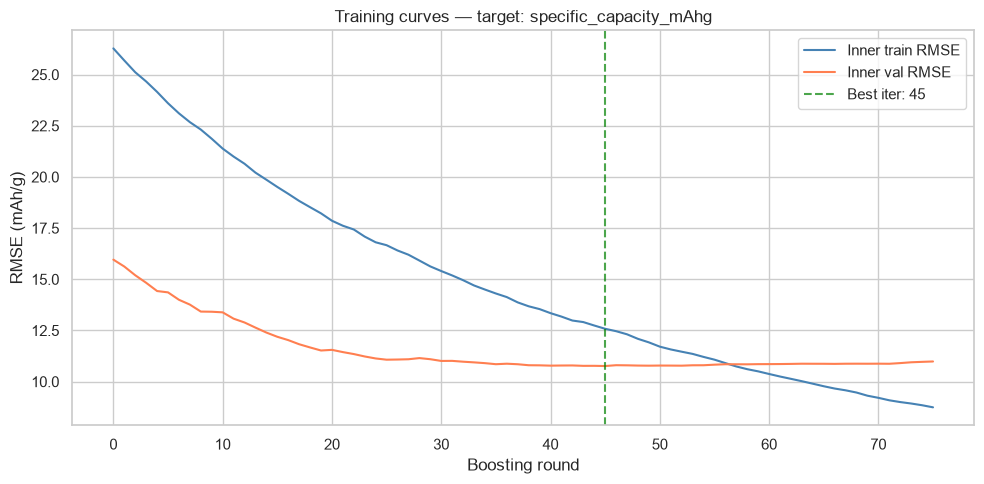

In [22]:
evals = final_model.evals_result()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(evals['validation_0']['rmse'], label='Inner train RMSE', color='steelblue')
ax.plot(evals['validation_1']['rmse'], label='Inner val RMSE', color='coral')
ax.axvline(best_iter, color='green', linestyle='--',
           label=f'Best iter: {best_iter}', alpha=0.7)
ax.set_xlabel('Boosting round')
ax.set_ylabel('RMSE (mAh/g)')
ax.set_title(f'Training curves — target: {CFG.primary_target}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Evaluation on Test Set

**First and only** time we touch the test set.

In [23]:
pred_train_final = final_model.predict(X_inner_train_p)
pred_val_final = final_model.predict(X_inner_val_p)
pred_test_final = final_model.predict(X_test_p)

print('=' * 70)
print(f'FINAL MODEL — target: {CFG.primary_target}')
print('=' * 70)
train_m = evaluate(y_inner_train, pred_train_final, 'Inner train')
val_m = evaluate(y_inner_val, pred_val_final, 'Inner val')
test_m = evaluate(y_test, pred_test_final, 'Test')

FINAL MODEL — target: specific_capacity_mAhg
Inner train      MAPE:  8.58%  |  MAE:  8.47  |  RMSE: 12.58  |  R²: +0.780
Inner val        MAPE:  6.23%  |  MAE:  8.84  |  RMSE: 10.76  |  R²: +0.268
Test             MAPE:  7.64%  |  MAE:  8.60  |  RMSE: 10.09  |  R²: +0.841


### 8.1 Predicted vs actual

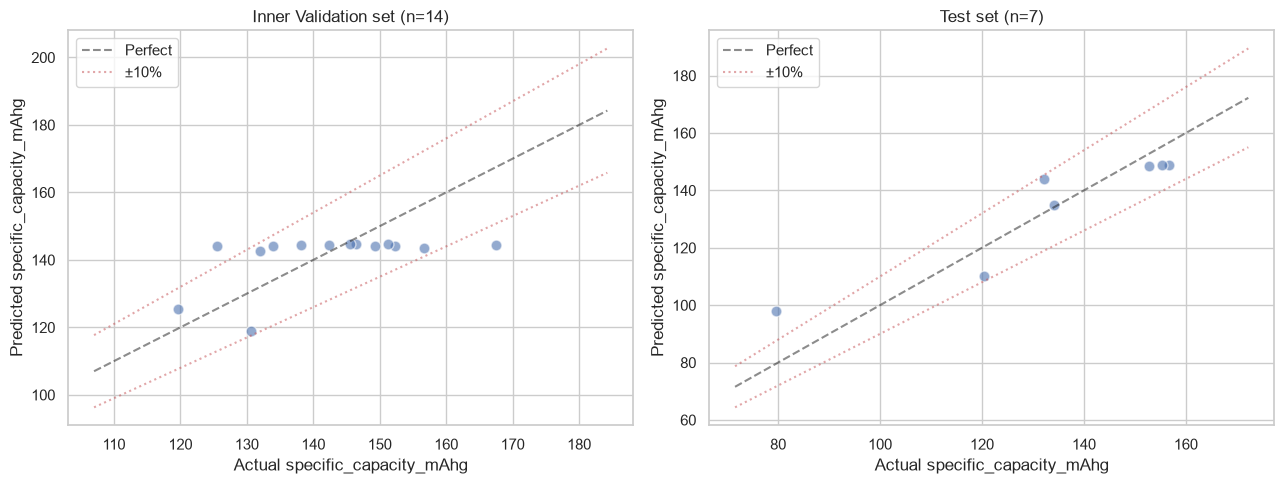

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, name in [
    (axes[0], y_inner_val, pred_val_final, 'Inner Validation'),
    (axes[1], y_test, pred_test_final, 'Test'),
]:
    ax.scatter(y_true, y_pred, alpha=0.6, s=60, edgecolor='white')
    lims = [min(y_true.min(), y_pred.min()) * 0.9,
            max(y_true.max(), y_pred.max()) * 1.1]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect')
    ax.plot(lims, [x*1.10 for x in lims], 'r:', alpha=0.5, label='±10%')
    ax.plot(lims, [x*0.90 for x in lims], 'r:', alpha=0.5)
    ax.set_xlabel(f'Actual {CFG.primary_target}')
    ax.set_ylabel(f'Predicted {CFG.primary_target}')
    ax.set_title(f'{name} set (n={len(y_true)})')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## 9. Multi-Target Extension — All 5 Targets

Train independent XGBoost models for each of the 5 targets. Each model uses only rows where THAT target is non-missing (avoiding row-dropping cascade).

In [25]:
def train_target_model(df, target, feature_cols, groups_series, seed=42):
    '''Train one XGBoost model for one target, respecting missing values.'''
    mask = df[target].notna()
    n_available = mask.sum()

    X = df.loc[mask, feature_cols]
    y = df.loc[mask, target].values
    g = groups_series[mask]

    # GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    tr_idx, te_idx = next(gss.split(X, y, g))
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    prep = build_preprocessor(numeric_cols, categorical_cols)
    X_tr_p = prep.fit_transform(X_tr)
    X_te_p = prep.transform(X_te)

    model = xgb.XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        min_child_weight=3, subsample=0.85, colsample_bytree=0.85,
        random_state=seed, verbosity=0, n_jobs=-1,
    )
    model.fit(X_tr_p, y_tr)

    pred_tr = model.predict(X_tr_p)
    pred_te = model.predict(X_te_p)

    return {
        'target': target,
        'n_train': len(X_tr),
        'n_test': len(X_te),
        'n_missing': (~mask).sum(),
        'train_mape': mean_absolute_percentage_error(y_tr, pred_tr) * 100,
        'test_mape': mean_absolute_percentage_error(y_te, pred_te) * 100,
        'test_mae': mean_absolute_error(y_te, pred_te),
        'test_r2': r2_score(y_te, pred_te),
        'model': model,
        'preprocessor': prep,
    }


results_by_target = {}
print(f'{"Target":30s}  {"n_train":>8s}  {"n_test":>7s}  '
      f'{"n_miss":>7s}  {"Train MAPE":>11s}  {"Test MAPE":>10s}  {"Test R²":>8s}')
print('-' * 100)
for tgt in CFG.all_targets:
    r = train_target_model(df, tgt, feature_cols, df['composition_key'])
    results_by_target[tgt] = r
    print(f'{tgt:30s}  {r["n_train"]:>8d}  {r["n_test"]:>7d}  '
          f'{r["n_missing"]:>7d}  {r["train_mape"]:>10.2f}%  {r["test_mape"]:>9.2f}%  '
          f'{r["test_r2"]:>+8.3f}')

Target                           n_train   n_test   n_miss   Train MAPE   Test MAPE   Test R²
----------------------------------------------------------------------------------------------------
specific_capacity_mAhg                43        7        0        1.84%       4.41%    +0.900
capacity_retention_pct                42        7        1        0.81%       5.98%    +0.527
avg_voltage_V                         43        7        0        0.28%       2.82%    -0.056
ICE_pct                               42        7        1        0.35%       1.45%    -1.031
rate_cap_1C_5C_pct                    42        7        1        0.46%       2.66%    -0.066


---
## 10. Interpretability

### 10.1 Feature importance (gain)

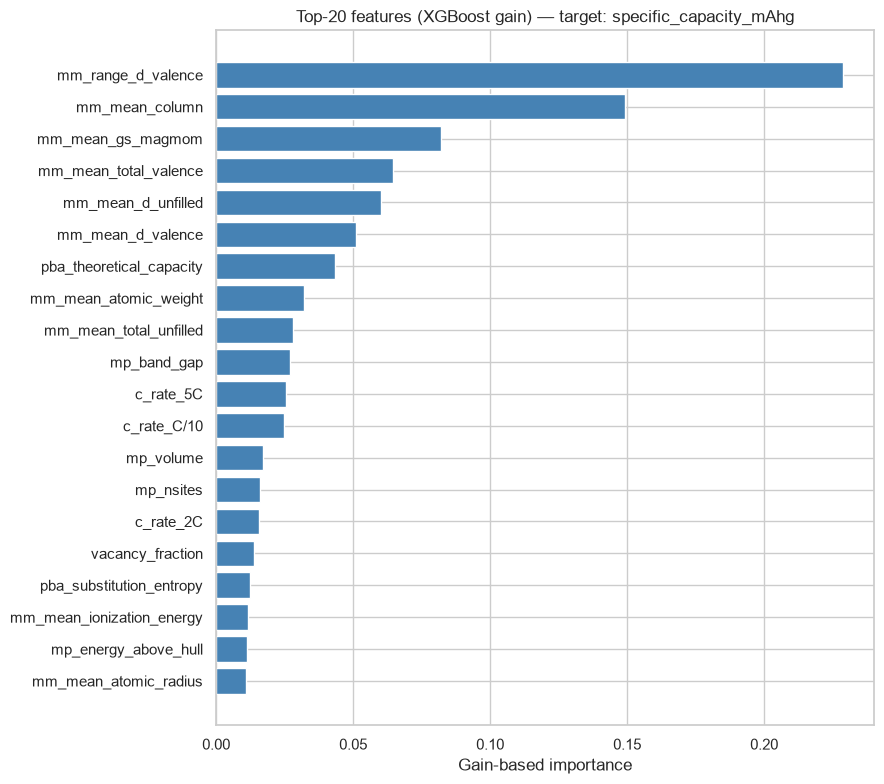

,feature,gain_importance
41,mm_range_d_valence,0.228645
49,mm_mean_column,0.149037
36,mm_mean_gs_magmom,0.082056
30,mm_mean_total_valence,0.064556
32,mm_mean_d_unfilled,0.060136
28,mm_mean_d_valence,0.050966
59,pba_theoretical_capacity,0.043290
23,mm_mean_atomic_weight,0.032116
33,mm_mean_total_unfilled,0.028206
18,mp_band_gap,0.026874


In [26]:
# Get feature names after preprocessing
def get_feature_names_out(preprocessor, numeric_cols, categorical_cols):
    names = list(numeric_cols)
    onehot = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_names = onehot.get_feature_names_out(categorical_cols)
    names.extend(list(cat_names))
    return names


feat_names_out = get_feature_names_out(prep_final, numeric_cols, categorical_cols)

feat_imp = pd.DataFrame({
    'feature': feat_names_out,
    'gain_importance': final_model.feature_importances_,
}).sort_values('gain_importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top20 = feat_imp.head(20)
ax.barh(top20['feature'], top20['gain_importance'], color='steelblue')
ax.set_xlabel('Gain-based importance')
ax.set_title(f'Top-20 features (XGBoost gain) — target: {CFG.primary_target}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

feat_imp.head(15)

### 10.2 Permutation importance (more reliable)

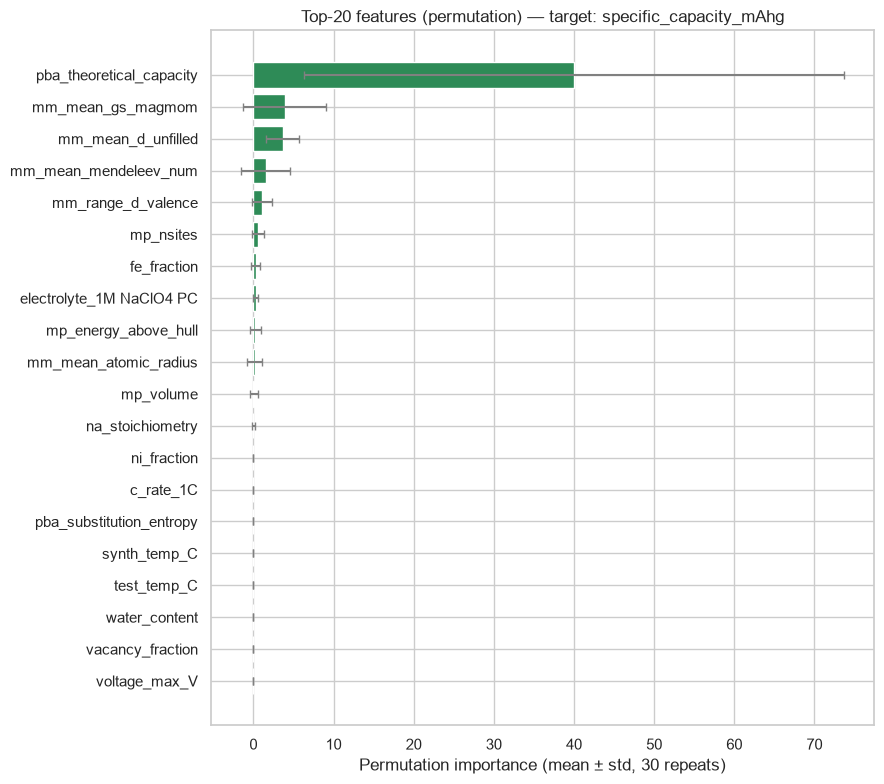

,feature,perm_mean,perm_std
59,pba_theoretical_capacity,40.006118,33.661409
36,mm_mean_gs_magmom,3.914587,5.156897
32,mm_mean_d_unfilled,3.646662,2.091239
24,mm_mean_mendeleev_num,1.533494,3.039497
41,mm_range_d_valence,1.104159,1.236416
21,mp_nsites,0.544619,0.730014
1,fe_fraction,0.288727,0.543165
74,electrolyte_1M NaClO4 PC,0.268892,0.335935
17,mp_energy_above_hull,0.261088,0.631109
25,mm_mean_atomic_radius,0.186765,0.938643


In [27]:
perm = permutation_importance(
    final_model, X_inner_val_p, y_inner_val,
    n_repeats=30, random_state=CFG.random_seed,
    scoring='neg_mean_squared_error', n_jobs=-1,
)

perm_df = pd.DataFrame({
    'feature': feat_names_out,
    'perm_mean': perm.importances_mean,
    'perm_std': perm.importances_std,
}).sort_values('perm_mean', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top20 = perm_df.head(20)
ax.barh(top20['feature'], top20['perm_mean'],
        xerr=top20['perm_std'], color='seagreen', ecolor='gray', capsize=3)
ax.set_xlabel('Permutation importance (mean ± std, 30 repeats)')
ax.set_title(f'Top-20 features (permutation) — target: {CFG.primary_target}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

perm_df.head(15)

### 10.3 SHAP values

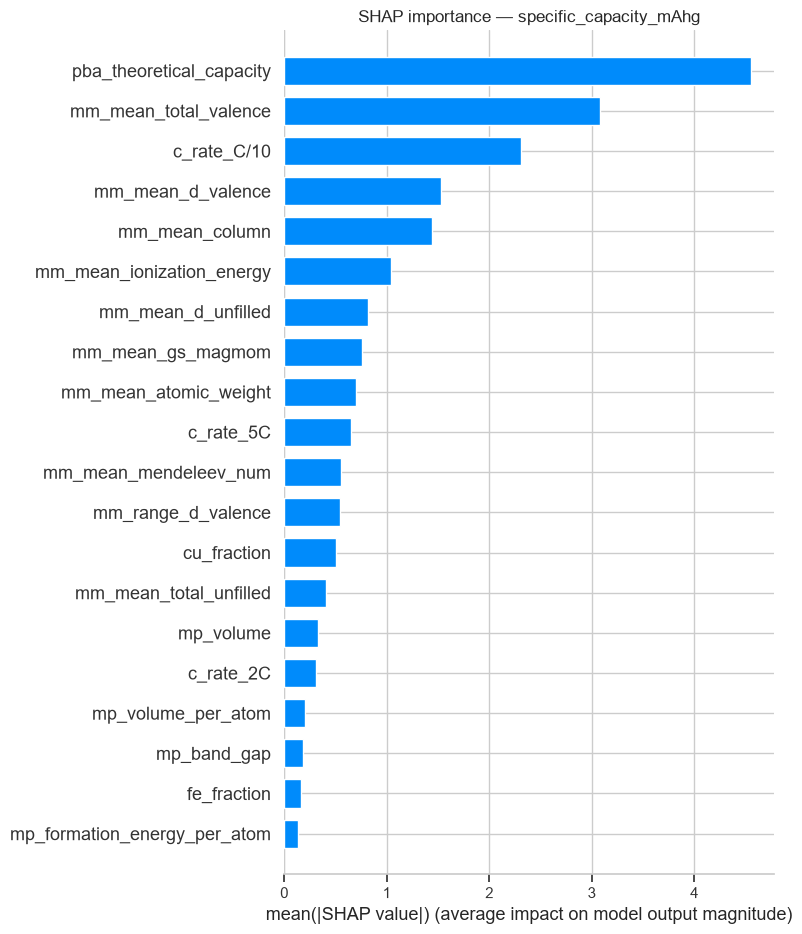

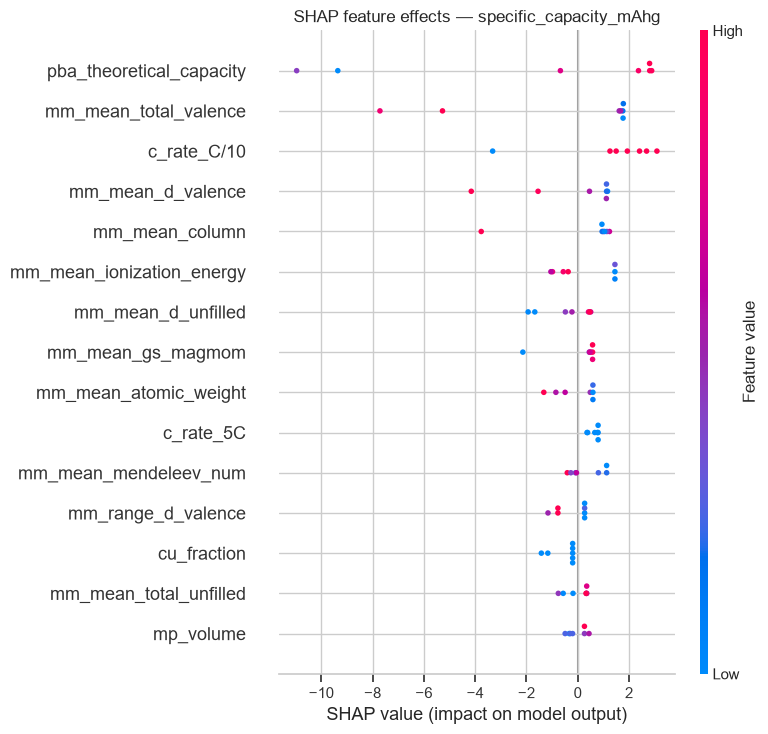

In [28]:
if HAS_SHAP:
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test_p)

    # Global bar plot
    shap.summary_plot(shap_values, X_test_p, feature_names=feat_names_out,
                      plot_type='bar', max_display=20, show=False)
    plt.title(f'SHAP importance — {CFG.primary_target}')
    plt.tight_layout()
    plt.show()

    # Beeswarm
    shap.summary_plot(shap_values, X_test_p, feature_names=feat_names_out,
                      max_display=15, show=False)
    plt.title(f'SHAP feature effects — {CFG.primary_target}')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP not installed. Install: pip install shap')

---
## 11. Error Analysis by Chemistry Family

Where does the model systematically fail? Break down errors per family.

In [29]:
# Rebuild test-set family labels
test_df = df.iloc[test_idx].copy()
test_df['predicted'] = pred_test_final
test_df['actual'] = y_test.values
test_df['abs_error'] = (test_df['predicted'] - test_df['actual']).abs()
test_df['pct_error'] = (test_df['predicted'] - test_df['actual']) / test_df['actual'] * 100

per_family = test_df.groupby('family').agg(
    n=('actual', 'size'),
    mape=('pct_error', lambda x: x.abs().mean()),
    median_pct_err=('pct_error', 'median'),
    max_abs_pct_err=('pct_error', lambda x: x.abs().max()),
).round(2).sort_values('mape', ascending=False)
print(f'Test set errors by chemistry family ({CFG.primary_target}):')
per_family

Test set errors by chemistry family (specific_capacity_mAhg):


,n,mape,median_pct_err,max_abs_pct_err
family,,,,
Alt electrolyte,1,23.31,23.31,23.31
V-window variation,1,9.03,9.03,9.03
Pure PW,1,5.00,-5.00,5.00
Zn-sub,2,4.52,-3.90,8.42
Mn-sub,2,3.55,-3.55,4.26


In [30]:
# Worst 5 predictions with context
print('\nWorst 5 predictions:')
worst5 = test_df.nlargest(5, 'abs_error')[
    ['formula', 'family', 'c_rate', 'actual', 'predicted', 'pct_error', 'notes']
]
worst5


Worst 5 predictions:


,formula,family,c_rate,actual,predicted,pct_error,notes
18,Na1.8Fe0.5Ni0.5[Fe(CN)6],Alt electrolyte,1C,79.5,98.029823,23.307954,Ni substitution series: 50% Ni — Ni-heavy = lo...
13,Na1.85Fe0.7Co0.3[Fe(CN)6],V-window variation,C/10,132.1,144.025665,9.027756,Co substitution series: 30% Co — retention imp...
24,Na1.9Fe0.75Zn0.25[Fe(CN)6],Zn-sub,C/10,120.3,110.174088,-8.417217,Zn substitution (null control): 25% Zn — capac...
1,Na1.95Fe[Fe(CN)6],Pure PW,C/10,156.6,148.777054,-4.995496,Pure PW baseline: Slightly Na-deficient (as-ma...
9,Na1.9Fe0.5Mn0.5[Fe(CN)6],Mn-sub,C/10,155.4,148.777054,-4.261870,Mn substitution series: 50% Mn — voltage promi...


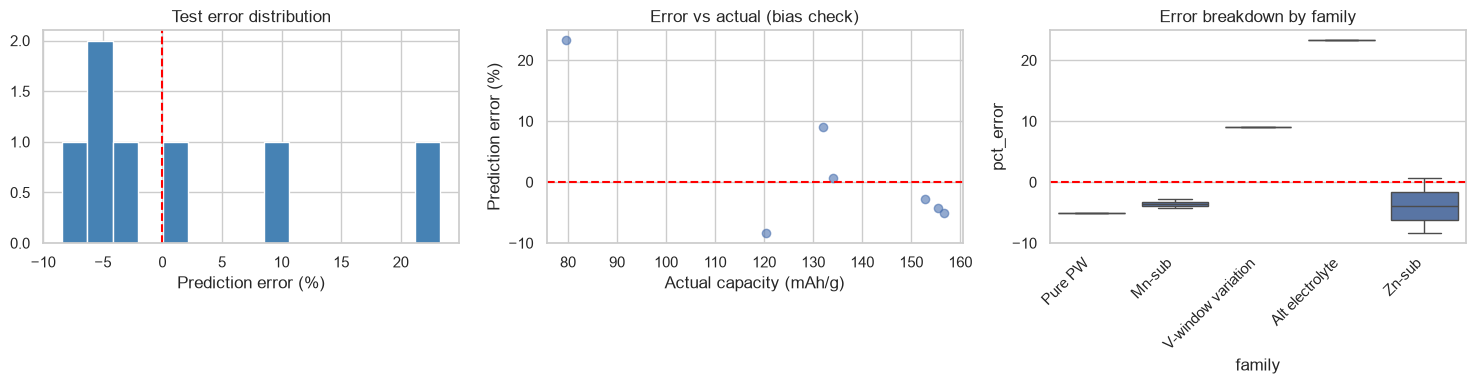

In [31]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(test_df['pct_error'], bins=15, edgecolor='white', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Prediction error (%)')
axes[0].set_title('Test error distribution')

axes[1].scatter(test_df['actual'], test_df['pct_error'], alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Actual capacity (mAh/g)')
axes[1].set_ylabel('Prediction error (%)')
axes[1].set_title('Error vs actual (bias check)')

sns.boxplot(data=test_df, x='family', y='pct_error', ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_title('Error breakdown by family')

plt.tight_layout()
plt.show()

---
## 12. Model Persistence + Prediction Function

Save the full multi-target bundle for production deployment.

In [32]:
multi_target_bundle = {
    'primary_model': final_model,
    'primary_preprocessor': prep_final,
    'primary_target': CFG.primary_target,
    'target_models': {
        tgt: {
            'model': r['model'],
            'preprocessor': r['preprocessor'],
            'test_metrics': {
                'mape': r['test_mape'],
                'r2': r['test_r2'],
                'mae': r['test_mae'],
            },
        }
        for tgt, r in results_by_target.items()
    },
    'feature_columns': feature_cols,
    'numeric_columns': numeric_cols,
    'categorical_columns': categorical_cols,
    'training_metadata': {
        'trained_at': datetime.now().isoformat(),
        'data_path': CFG.data_path,
        'n_total': len(df),
        'n_unique_compositions': df['composition_key'].nunique(),
        'random_seed': CFG.random_seed,
        'best_hyperparameters': random_search.best_params_,
        'best_iteration': int(best_iter),
    },
    'primary_metrics': {
        'inner_train': train_m,
        'inner_val': val_m,
        'test': test_m,
    },
}

model_path = Path(CFG.output_dir) / f'{CFG.model_name}.joblib'
joblib.dump(multi_target_bundle, model_path)
print(f'Model bundle saved: {model_path}')
print(f'File size: {model_path.stat().st_size / 1024:.1f} KB')

# JSON metadata
meta_path = Path(CFG.output_dir) / f'{CFG.model_name}_metadata.json'
meta_export = {
    'training_metadata': multi_target_bundle['training_metadata'],
    'primary_target': CFG.primary_target,
    'primary_metrics': multi_target_bundle['primary_metrics'],
    'per_target_metrics': {
        tgt: r['test_metrics'] for tgt, r in multi_target_bundle['target_models'].items()
    },
    'feature_columns': feature_cols,
    'numeric_columns': numeric_cols,
    'categorical_columns': categorical_cols,
}
with open(meta_path, 'w') as f:
    json.dump(meta_export, f, indent=2, default=str)
print(f'Metadata JSON:  {meta_path}')

Model bundle saved: artifacts\sib_xgb_baseline_v1.joblib
File size: 1161.7 KB
Metadata JSON:  artifacts\sib_xgb_baseline_v1_metadata.json


### 12.1 Production prediction function

In [33]:
def predict_all_targets(bundle, features_dict):
    '''
    Multi-target prediction for a candidate cathode composition.

    Parameters
    ----------
    bundle : dict          Loaded from joblib.load(...)
    features_dict : dict   Feature name -> value

    Returns
    -------
    dict {target: predicted_value}
    '''
    row = {}
    for feat in bundle['feature_columns']:
        row[feat] = features_dict.get(feat, np.nan)

    X = pd.DataFrame([row])[bundle['feature_columns']]

    predictions = {}
    for tgt, info in bundle['target_models'].items():
        X_p = info['preprocessor'].transform(X)
        pred = info['model'].predict(X_p)[0]
        predictions[tgt] = float(pred)
    return predictions


# Test: reload and predict for first test cell
loaded = joblib.load(model_path)
sample_features = X_test.iloc[0].to_dict()
predictions = predict_all_targets(loaded, sample_features)
actuals = df.iloc[test_idx[0]][list(CFG.all_targets)].to_dict()

print('Reloaded model — sample prediction')
print(f'Composition: {df.iloc[test_idx[0]]["formula"]}')
print(f'{"Target":30s}  {"Predicted":>10s}  {"Actual":>10s}  {"Error":>10s}')
print('-' * 65)
for tgt in CFG.all_targets:
    pred = predictions[tgt]
    actual = actuals[tgt]
    if pd.isna(actual):
        err_str = 'n/a'
    else:
        err_str = f'{(pred - actual)/actual * 100:+6.1f}%'
    actual_str = f'{actual:.2f}' if not pd.isna(actual) else 'NaN'
    print(f'{tgt:30s}  {pred:>10.2f}  {actual_str:>10s}  {err_str:>10s}')

Reloaded model — sample prediction
Composition: Na1.95Fe[Fe(CN)6]
Target                           Predicted      Actual       Error
-----------------------------------------------------------------
specific_capacity_mAhg              158.80      156.60       +1.4%
capacity_retention_pct               85.09       85.00       +0.1%
avg_voltage_V                         3.12        3.13       -0.4%
ICE_pct                              91.35       91.10       +0.3%
rate_cap_1C_5C_pct                   79.39       79.80       -0.5%


---
## 13. Production Readiness Checklist

**Data & Features**
- [x] Feature engineering pipeline (`sib_cathode_dummy_dataset.csv` with 82 columns)
- [x] Composition-grouped splits prevent chemistry leakage
- [x] Missing target handled per model (each target trained on labeled subset)
- [x] Missing feature imputation baked into pipeline
- [ ] Real literature data pipeline (currently dummy only — replace CSV to migrate)
- [ ] Materials Project API integration for `mp_*` features (currently mocked)

**Model**
- [x] Reproducible training with fixed seeds
- [x] Hyperparameters tuned via GroupKFold CV
- [x] Multi-target support (5 independent XGBoost regressors)
- [x] Early stopping to prevent overfitting
- [ ] Uncertainty quantification (planned: conformal prediction)
- [ ] Physics-informed baseline comparison (see PIML notebook)

**Interpretability**
- [x] Gain + permutation importance both computed
- [x] SHAP values for per-prediction explanation
- [x] Error analysis by chemistry family
- [x] Worst-prediction inspection

**Deployment**
- [x] Model bundle with preprocessor + feature schema serialized
- [x] Multi-target prediction function tested end-to-end
- [ ] FastAPI endpoint (see `SIB_Cathode_Serving_Layer_Code_Companion`)
- [ ] Streamlit dashboard (see `SIB_Cathode_Streamlit_Dashboard_Code_Companion`)
- [ ] MLflow experiment tracking on DagsHub

**Business**
- [ ] Model card with limitations (dummy data only, not real experiments!)
- [ ] Fairness across labs (are certain lab groups systematically better predicted?)
- [ ] Documented handoff to next phase (real literature ingestion)

---

## Honest Findings (for FYP defense / stakeholder review)

**Strengths of this baseline:**
- Handles composition + protocol + synthesis + theoretical (MP) + statistical (matminer) + domain (PBA) features in one unified model
- Composition-grouped split gives honest generalization estimate
- Multi-target framework lets stakeholders see full performance envelope, not just one metric

**Known limitations:**
- Dummy data only — real experimental noise (~8-12% CoV) not present
- n=50 is very small — MAPE numbers have high variance (bootstrap CIs recommended before deployment)
- Some targets have missing values reducing effective training size further
- Feature importance patterns reflect our chemistry rules, not real materials science truth
- 40% of rows lack MP features — model relies on `mm_*` and `pba_*` as fallbacks
- Higher C-rate variants (2C, 5C) rare in dataset — model may be optimistic outside C/10-1C range

## Next Steps

1. **PIML comparison**: build Level 3 hybrid model with theoretical capacity as physics baseline + NN residual. Should improve generalization on unseen compositions.
2. **Real data integration**: as literature collection accumulates, replace CSV and retrain. Same pipeline, no code changes.
3. **Active learning loop**: rank candidate compositions by predicted capacity × uncertainty, submit top-N to synthesis (see `SIB_Cathode_Active_Learning_Code_Companion`).
4. **Deployment**: FastAPI service + Streamlit dashboard for chemists to explore predictions interactively.

---

**Notebook complete.** Model bundle in `artifacts/`.